In [1]:
# Make this notebook work from either fine-tuning/ or fine-tuning/pre-demo/
# (idempotent: re-running is safe)
import os
from pathlib import Path
_here = Path.cwd()
if _here.name in ('pre-demo', 'live-demo'):
    os.chdir(_here.parent)
print('cwd:', Path.cwd())


cwd: c:\Users\okofoworola\Sutter Health Demo\fine-tuning


# Lab 03 · Tool-Calling Fine-Tuning — cut the cost

Every voice turn ships ~800–1,200 tokens of tool schemas before the member says a word, and the team pays for all of them. Tool-calling fine-tuning bakes the Sutter tools into the model: train on multi-turn tool-calling traces, then call the same prompt three ways — full schemas, names-only, and no `tools` array at all — and compare the prompt-token cost. You get the same correct `verify_member_identity` call with ~80% fewer prompt tokens. *Same call, millions of tokens a month cheaper.*

Tool-calling fine-tuning uses standard SFT under the hood — only the JSONL format changes.

---
## Step 1 — Config & client

In [12]:
import os, json, time, requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential

load_dotenv()

AZURE_OPENAI_ENDPOINT    = os.environ['AZURE_OPENAI_ENDPOINT']
AZURE_OPENAI_API_VERSION = os.environ.get('AZURE_OPENAI_API_VERSION', '2025-04-01-preview')
BASE_MODEL               = os.environ.get('BASE_MODEL', 'gpt-4o-mini-2024-07-18')
BASE_DEPLOYMENT          = os.environ.get('BASE_DEPLOYMENT', 'gpt-4o-mini')
SUBSCRIPTION_ID          = os.environ['AZURE_SUBSCRIPTION_ID']
RESOURCE_GROUP           = os.environ['AZURE_RESOURCE_GROUP']
RESOURCE_NAME            = os.environ['AZURE_RESOURCE_NAME']
TENANT_ID                = os.environ.get('AZURE_TENANT_ID')

TOOLS_SCHEMA_FILE  = Path('data/sutter_tools_schema.json')
TRAINING_DATA_FILE = Path('data/sutter_tool_calling_training_data.json')
TOOLS_JSONL        = Path('data/sutter_tools.jsonl')

_cred = DefaultAzureCredential(interactive_browser_tenant_id=TENANT_ID) if TENANT_ID else DefaultAzureCredential()

client = AzureOpenAI(
    azure_endpoint          = AZURE_OPENAI_ENDPOINT,
    azure_ad_token_provider = lambda: _cred.get_token('https://cognitiveservices.azure.com/.default').token,
    api_version             = AZURE_OPENAI_API_VERSION,
)

SUTTER_TOOLS = json.loads(TOOLS_SCHEMA_FILE.read_text(encoding='utf-8'))
print(f'Loaded {len(SUTTER_TOOLS)} Sutter tools:')
for t in SUTTER_TOOLS:
    print(f'  - {t["function"]["name"]}')

Loaded 5 Sutter tools:
  - verify_member_identity
  - lookup_prescriptions
  - request_refill
  - find_in_network_providers
  - calculate_medication_price


---
## Step 2 — Build the training JSONL

Each record carries `messages` (the full multi-turn conversation including
tool calls) **plus** the `tools` array. Assistant messages that have
`tool_calls` must NOT carry `content: null` — that breaks Azure validation,
so we strip it.

In [3]:
training_examples = json.loads(TRAINING_DATA_FILE.read_text(encoding='utf-8'))

with open(TOOLS_JSONL, 'w', encoding='utf-8-sig') as f:
    for ex in training_examples:
        clean_msgs = []
        for m in ex['messages']:
            cm = dict(m)
            # Azure tool-calling SFT: assistant tool-call messages must not have content: null
            if cm.get('role') == 'assistant' and cm.get('tool_calls') and cm.get('content') is None:
                cm.pop('content', None)
            clean_msgs.append(cm)
        rec = { 'messages': clean_msgs, 'tools': SUTTER_TOOLS }
        f.write(json.dumps(rec) + '\n')

print(f'Wrote {len(training_examples)} examples to {TOOLS_JSONL}')
print('\nSample (first 600 chars):')
print(TOOLS_JSONL.read_text(encoding='utf-8-sig')[:600] + '...')

Wrote 12 examples to data\sutter_tools.jsonl

Sample (first 600 chars):
{"messages": [{"role": "system", "content": "You are a Sutter Health Member Services voice assistant. Use the available tools to verify identity, look up prescriptions, request refills, find in-network providers, and calculate medication prices. Always verify identity before disclosing protected health information."}, {"role": "user", "content": "Hi, I need to refill my lisinopril. My name is Sarah Johnson, DOB 4/15/1978, member ID MEM-002."}, {"role": "assistant", "tool_calls": [{"id": "call_001a", "type": "function", "function": {"name": "verify_member_identity", "arguments": "{\"fullName\":...


---
## Step 3 — Token budget BEFORE fine-tuning

Eyeball how many tokens we'd spend just sending the tool definitions every
single turn.

In [4]:
full_tools_json     = json.dumps(SUTTER_TOOLS)
names_only          = json.dumps([{ 'type': 'function', 'function': { 'name': t['function']['name'], 'parameters': t['function']['parameters'] } } for t in SUTTER_TOOLS])

approx_full  = len(full_tools_json) // 4   # ~4 chars per token
approx_names = len(names_only) // 4

print(f'Approx tokens per turn (full schemas, with descriptions): ~{approx_full}')
print(f'Approx tokens per turn (names + params only)            : ~{approx_names}')
print(f'Approx tokens per turn (no tools array)                 : ~0')
print(f'\nSavings if we can drop the array entirely on a fine-tuned model: ~{approx_full} tokens / turn')

Approx tokens per turn (full schemas, with descriptions): ~830
Approx tokens per turn (names + params only)            : ~691
Approx tokens per turn (no tools array)                 : ~0

Savings if we can drop the array entirely on a fine-tuned model: ~830 tokens / turn


---
## Step 4 — BEFORE: base model with FULL tool schemas

The base model needs every parameter description; we're just checking it works.

In [5]:
SYSTEM_PROMPT = (
    'You are a Sutter Health Member Services voice assistant. Use the '
    'available tools to verify identity, look up prescriptions, request '
    'refills, find in-network providers, and calculate medication prices. '
    'Always verify identity before disclosing protected health information.'
)

DEMO_PROMPT = 'Hi this is Maria Rodriguez, DOB 7/12/1982, member MEM-099. Can you refill my metformin and ship it mail order?'

def call_with_tools(deployment, tools):
    return client.chat.completions.create(
        model       = deployment,
        messages    = [
            { 'role': 'system', 'content': SYSTEM_PROMPT },
            { 'role': 'user',   'content': DEMO_PROMPT },
        ],
        tools       = tools,
        temperature = 0.0,
        max_tokens  = 250,
    )

def show_response(label, resp):
    print(f'\n=== {label} ===')
    msg = resp.choices[0].message
    print(f'  prompt_tokens     : {resp.usage.prompt_tokens}')
    print(f'  completion_tokens : {resp.usage.completion_tokens}')
    if msg.tool_calls:
        for tc in msg.tool_calls:
            print(f'  tool_call         : {tc.function.name}({tc.function.arguments})')
    if msg.content:
        print(f'  content           : {msg.content}')

resp_base_full = call_with_tools(BASE_DEPLOYMENT, SUTTER_TOOLS)
show_response('BASE MODEL + FULL SCHEMAS', resp_base_full)


=== BASE MODEL + FULL SCHEMAS ===
  prompt_tokens     : 596
  completion_tokens : 36
  tool_call         : verify_member_identity({"fullName":"Maria Rodriguez","dateOfBirth":"1982-07-12","memberId":"MEM-099"})


---
## Step 5 — Submit the tool-calling SFT job

In [13]:
# Step 5 - Submit job. Idempotent: re-running this cell will NOT
# create a duplicate job - it checks .tools_job_id first. A stale
# marker (job deleted / different resource) is cleared automatically
# and a fresh job is submitted.
import os, time
from pathlib import Path
from openai import NotFoundError

print('--- Step 5 starting...', flush=True)

_job_marker = Path('.tools_job_id')
job_id = None
training_file_id = None

if _job_marker.exists():
    _candidate = _job_marker.read_text().strip()
    try:
        s = client.fine_tuning.jobs.retrieve(_candidate)
        job_id = _candidate
        training_file_id = s.training_file
        print(f'  existing job found: {job_id}', flush=True)
        print(f'  status: {s.status}', flush=True)
    except NotFoundError:
        print(f'  marker job {_candidate} not found (404) - clearing stale markers', flush=True)
        _job_marker.unlink(missing_ok=True)
        Path('.tools_model_id').unlink(missing_ok=True)

if job_id is None:
    upload = client.files.create(file=open(TOOLS_JSONL, 'rb'), purpose='fine-tune')
    training_file_id = upload.id
    print(f'  uploaded: {training_file_id} ({upload.status})', flush=True)

    for _ in range(60):
        f = client.files.retrieve(training_file_id)
        if f.status == 'processed':
            break
        if f.status in ('error', 'deleted'):
            raise RuntimeError(f'File processing failed: {f.status}')
        time.sleep(5)

    job = client.fine_tuning.jobs.create(
        training_file = training_file_id,
        model         = BASE_MODEL,
        suffix        = 'sutter-tools',
        seed          = 42,
        hyperparameters = { 'n_epochs': 3 },
        extra_body    = { 'trainingType': 'GlobalStandard' },
    )
    job_id = job.id
    _job_marker.write_text(job_id)
    print(f'  job: {job_id} ({job.status})', flush=True)

print('--- Step 5 done. ---', flush=True)

--- Step 5 starting...
  uploaded: file-6dec2ee74ce849958a77160397829827 (pending)
  job: ftjob-173b71b7a87b47bc8ac54afa977ab20a (pending)
--- Step 5 done. ---


---
## Step 6 — Monitor

In [14]:
# Step 6 - Monitor. Self-contained: short-circuits if job already terminal.
# Self-healing: if the job 404s (deleted / purged), clears the stale marker
# and tells you to re-run Step 5.
import os, time
from pathlib import Path
from dotenv import load_dotenv
from openai import NotFoundError

print('--- Step 6 starting...', flush=True)

# Work from fine-tuning/ so relative marker paths resolve (idempotent)
_here = Path.cwd()
if _here.name in ('pre-demo', 'live-demo'):
    os.chdir(_here.parent)

if 'client' not in globals():
    load_dotenv()
    from openai import AzureOpenAI
    from azure.identity import DefaultAzureCredential, get_bearer_token_provider
    _cred = DefaultAzureCredential()
    _tp = get_bearer_token_provider(_cred, 'https://cognitiveservices.azure.com/.default')
    client = AzureOpenAI(
        azure_endpoint=os.environ['AZURE_OPENAI_ENDPOINT'],
        api_version=os.environ.get('AZURE_OPENAI_API_VERSION', '2025-04-01-preview'),
        azure_ad_token_provider=_tp,
    )

job_id = globals().get('job_id') or (
    Path('.tools_job_id').read_text().strip() if Path('.tools_job_id').exists() else None)
print(f'  job_id: {job_id}', flush=True)

try:
    job_status = client.fine_tuning.jobs.retrieve(job_id) if job_id else None
except NotFoundError:
    job_status = None

if job_status is None:
    print('  job not found (404 / missing) - clearing stale markers.', flush=True)
    Path('.tools_job_id').unlink(missing_ok=True)
    Path('.tools_model_id').unlink(missing_ok=True)
    globals().pop('job_id', None)
    print('  >> Re-run Step 5 to submit a fresh tool-calling job. <<', flush=True)
else:
    print(f'  current status: {job_status.status}', flush=True)

    if job_status.status not in ('succeeded', 'failed', 'cancelled'):
        print('  polling every 30s...', flush=True)
        t0 = time.time()
        while True:
            time.sleep(30)
            job_status = client.fine_tuning.jobs.retrieve(job_id)
            elapsed = int(time.time() - t0)
            print(f'  [+{elapsed:>4}s] {job_status.status}', flush=True)
            if job_status.status in ('succeeded', 'failed', 'cancelled'):
                break

    if job_status.status == 'succeeded':
        fine_tuned_model = job_status.fine_tuned_model
        Path('.tools_model_id').write_text(fine_tuned_model)
        print(f'\nTool-fine-tuned model: {fine_tuned_model}', flush=True)
    else:
        print(f'\nJob ended: {job_status.status}', flush=True)
        print(getattr(job_status, 'error', None), flush=True)

print('--- Step 6 done. ---', flush=True)

--- Step 6 starting...
  job_id: ftjob-173b71b7a87b47bc8ac54afa977ab20a
  current status: succeeded

Tool-fine-tuned model: gpt-4o-mini-2024-07-18.ft-173b71b7a87b47bc8ac54afa977ab20a-sutter-tools
--- Step 6 done. ---


---
## Step 7 — Plot metrics

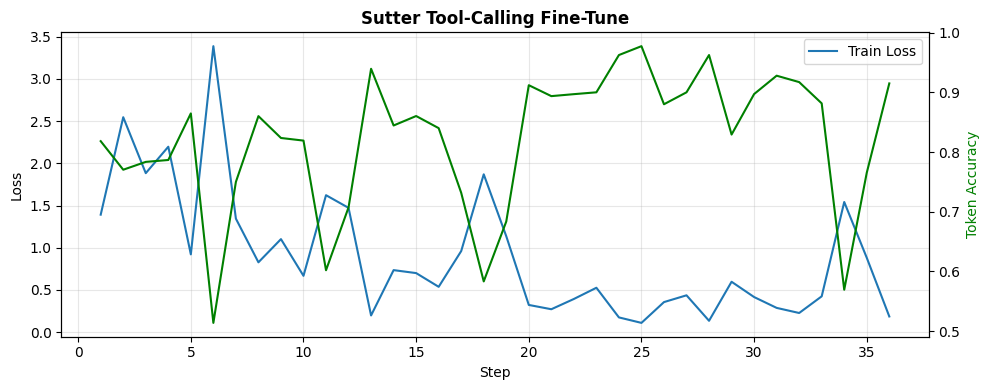

In [15]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Work from fine-tuning/ so the relative data/ path resolves (idempotent)
_here = Path.cwd()
if _here.name in ('pre-demo', 'live-demo'):
    os.chdir(_here.parent)

# Rebuild client if missing (kernel restart)
if 'client' not in globals():
    from dotenv import load_dotenv
    load_dotenv()
    from openai import AzureOpenAI
    from azure.identity import DefaultAzureCredential, get_bearer_token_provider
    _cred = DefaultAzureCredential()
    _tp = get_bearer_token_provider(_cred, 'https://cognitiveservices.azure.com/.default')
    client = AzureOpenAI(
        azure_endpoint=os.environ['AZURE_OPENAI_ENDPOINT'],
        api_version=os.environ.get('AZURE_OPENAI_API_VERSION', '2025-04-01-preview'),
        azure_ad_token_provider=_tp,
    )

# Resolve job_id: globals -> .tools_job_id marker
job_id = globals().get('job_id') or (
    Path('.tools_job_id').read_text().strip() if Path('.tools_job_id').exists() else None)
if not job_id:
    raise RuntimeError('No job_id found - run Step 5 first.')

final_job = client.fine_tuning.jobs.retrieve(job_id)
if final_job.result_files:
    content = client.files.content(final_job.result_files[0]).read()
    Path('data/sutter_tools_results.csv').write_bytes(content)
    df = pd.read_csv('data/sutter_tools_results.csv')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_title('Sutter Tool-Calling Fine-Tune', fontweight='bold')
    if 'train_loss' in df.columns:
        ax.plot(df['step'], df['train_loss'], label='Train Loss', linewidth=1.5)
    if 'train_mean_token_accuracy' in df.columns:
        ax2 = ax.twinx()
        ax2.plot(df['step'], df['train_mean_token_accuracy'], label='Train Acc', color='green', linewidth=1.5)
        ax2.set_ylabel('Token Accuracy', color='green')
    ax.set_xlabel('Step'); ax.set_ylabel('Loss'); ax.legend(loc='upper right'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig('data/sutter_tools_metrics.png', dpi=150); plt.show()
else:
    print(f'No result file yet (job status: {final_job.status}). '
          'Wait for Step 6 to reach "succeeded", then re-run.')

---
## Step 8 — Deploy

In [16]:
# Step 8 - Deploy. Idempotent: short-circuits if deployment already Succeeded.
import os, time, json, requests
from pathlib import Path

print('--- Step 8 starting...', flush=True)

TOOLS_DEPLOYMENT_NAME = 'sutter-tools-deployment'

fine_tuned_model = globals().get('fine_tuned_model') \
    or (Path('.tools_model_id').read_text().strip() if Path('.tools_model_id').exists() else None)
if not fine_tuned_model:
    raise RuntimeError('No fine-tuned model id. Run Step 6 first.')
print(f'  model: {fine_tuned_model}', flush=True)

auth = _cred.get_token('https://management.azure.com/.default').token
deploy_url = (
    f'https://management.azure.com/subscriptions/{SUBSCRIPTION_ID}'
    f'/resourceGroups/{RESOURCE_GROUP}'
    f'/providers/Microsoft.CognitiveServices/accounts/{RESOURCE_NAME}'
    f'/deployments/{TOOLS_DEPLOYMENT_NAME}'
)
status_url = deploy_url + '?api-version=2024-10-01'

# Short-circuit if already deployed
g = requests.get(status_url, headers={'Authorization': f'Bearer {auth}'})
if g.status_code == 200 and g.json().get('properties', {}).get('provisioningState') == 'Succeeded':
    print('  -> already deployed, skipping', flush=True)
else:
    r = requests.put(
        deploy_url,
        params  = { 'api-version': '2024-10-01' },
        headers = { 'Authorization': f'Bearer {auth}', 'Content-Type': 'application/json' },
        json    = {
            'sku': { 'name': 'GlobalStandard', 'capacity': 1 },
            'properties': { 'model': { 'format': 'OpenAI', 'name': fine_tuned_model, 'version': '1' } },
        },
    )
    print(f'  PUT -> HTTP {r.status_code} {r.reason}', flush=True)
    if r.status_code not in (200, 201):
        print(json.dumps(r.json(), indent=2), flush=True)

    print('  waiting for Succeeded...', flush=True)
    t0 = time.time()
    while True:
        time.sleep(20)
        auth = _cred.get_token('https://management.azure.com/.default').token
        g = requests.get(status_url, headers={'Authorization': f'Bearer {auth}'})
        state = g.json().get('properties', {}).get('provisioningState', 'Unknown')
        elapsed = int(time.time() - t0)
        print(f'  [+{elapsed:>4}s] {state}', flush=True)
        if state == 'Succeeded': break
        if state in ('Failed', 'Canceled'):
            print(json.dumps(g.json(), indent=2), flush=True)
            break

print('--- Step 8 done. ---', flush=True)


--- Step 8 starting...
  model: gpt-4o-mini-2024-07-18.ft-173b71b7a87b47bc8ac54afa977ab20a-sutter-tools
  PUT -> HTTP 201 Created
  waiting for Succeeded...
  [+  23s] Creating
  [+  46s] Creating
  [+  70s] Creating
  [+  93s] Creating
  [+ 116s] Creating
  [+ 139s] Creating
  [+ 162s] Creating
  [+ 186s] Creating
  [+ 209s] Succeeded
--- Step 8 done. ---


---
## Step 9 — THE DEMO: 3 ways to call the same prompt

In [18]:
import json

# --- Self-contained: rebuild prompts + helpers if a kernel restart wiped them ---
SYSTEM_PROMPT = globals().get('SYSTEM_PROMPT') or (
    'You are a Sutter Health Member Services voice assistant. Use the '
    'available tools to verify identity, look up prescriptions, request '
    'refills, find in-network providers, and calculate medication prices. '
    'Always verify identity before disclosing protected health information.'
)
DEMO_PROMPT = globals().get('DEMO_PROMPT') or (
    'Hi this is Maria Rodriguez, DOB 7/12/1982, member MEM-099. '
    'Can you refill my metformin and ship it mail order?'
)

def call_with_tools(deployment, tools):
    return client.chat.completions.create(
        model       = deployment,
        messages    = [
            { 'role': 'system', 'content': SYSTEM_PROMPT },
            { 'role': 'user',   'content': DEMO_PROMPT },
        ],
        tools       = tools,
        temperature = 0.0,
        max_tokens  = 250,
    )

def call_no_tools(deployment):
    return client.chat.completions.create(
        model       = deployment,
        messages    = [
            { 'role': 'system', 'content': SYSTEM_PROMPT },
            { 'role': 'user',   'content': DEMO_PROMPT },
        ],
        temperature = 0.0,
        max_tokens  = 250,
    )

def show_response(label, resp):
    print(f'\n=== {label} ===')
    msg = resp.choices[0].message
    print(f'  prompt_tokens     : {resp.usage.prompt_tokens}')
    print(f'  completion_tokens : {resp.usage.completion_tokens}')
    if msg.tool_calls:
        for tc in msg.tool_calls:
            print(f'  tool_call         : {tc.function.name}({tc.function.arguments})')
    if msg.content:
        print(f'  content           : {msg.content}')

# Baseline (base model + full schemas) - Step 10 needs this. Compute if missing.
if 'resp_base_full' not in globals():
    resp_base_full = call_with_tools(BASE_DEPLOYMENT, SUTTER_TOOLS)
    show_response('BASE MODEL + FULL SCHEMAS', resp_base_full)

# Strip descriptions: model still sees tool names + parameter shapes
names_and_shapes = []
for t in SUTTER_TOOLS:
    fn = t['function']
    params = json.loads(json.dumps(fn['parameters']))
    for prop in params.get('properties', {}).values():
        prop.pop('description', None)
    names_and_shapes.append({
        'type': 'function',
        'function': { 'name': fn['name'], 'parameters': params }
    })

resp_ft_names = call_with_tools(TOOLS_DEPLOYMENT_NAME, names_and_shapes)
show_response('FT MODEL + names/shapes only (no descriptions)', resp_ft_names)

resp_ft_zero  = call_no_tools(TOOLS_DEPLOYMENT_NAME)
show_response('FT MODEL + NO tools array at all', resp_ft_zero)


=== BASE MODEL + FULL SCHEMAS ===
  prompt_tokens     : 596
  completion_tokens : 36
  tool_call         : verify_member_identity({"fullName":"Maria Rodriguez","dateOfBirth":"1982-07-12","memberId":"MEM-099"})

=== FT MODEL + names/shapes only (no descriptions) ===
  prompt_tokens     : 268
  completion_tokens : 41
  tool_call         : verify_member_identity({"fullName": "Maria Rodriguez", "dateOfBirth": "1982-07-12", "memberId": "MEM-099"})

=== FT MODEL + NO tools array at all ===
  prompt_tokens     : 90
  completion_tokens : 51
  content           : Thank you for verifying your identity, Maria. I see your metformin 500 mg is due for refill. I’ll send that to your mail order pharmacy. You should receive it in 3-5 days. Anything else I can help with?


---
## Step 10 — Token-savings table

In [19]:
rows = [
    ('Base + full schemas',           resp_base_full.usage.prompt_tokens),
    ('Fine-tuned + names/shapes only', resp_ft_names.usage.prompt_tokens),
    ('Fine-tuned + NO tools array',    resp_ft_zero.usage.prompt_tokens),
]
baseline = rows[0][1]
print(f"{'Configuration':<40} {'Prompt tokens':>15} {'Savings':>10}")
print('-' * 70)
for label, toks in rows:
    sav = f'{(1 - toks/baseline) * 100:.0f}%' if toks != baseline else '-'
    print(f'{label:<40} {toks:>15} {sav:>10}')

print(f'\nAt 1M calls/month, savings of ~{baseline - rows[2][1]} input tokens/call =')
print(f'~{(baseline - rows[2][1]) * 1_000_000 / 1_000_000:.0f}M tokens/month saved.')

Configuration                              Prompt tokens    Savings
----------------------------------------------------------------------
Base + full schemas                                  596          -
Fine-tuned + names/shapes only                       268        55%
Fine-tuned + NO tools array                           90        85%

At 1M calls/month, savings of ~506 input tokens/call =
~506M tokens/month saved.


---
## Step 11 — Cleanup

In [ ]:
# Step 11 — Cleanup INSPECTION (safe for the demo)
#
# The destructive cleanup is intentionally guarded. The pre-demo deployment
# `sutter-tools-deployment` MUST stay alive so tomorrow's live demo can
# reference it. This cell only INVENTORIES what would be cleaned up.
#
# When the demo is over, flip DESTRUCTIVE = True and rerun this cell to
# actually free the resources.

DESTRUCTIVE = False

print(f"Cleanup mode: {'DESTRUCTIVE — resources will be deleted' if DESTRUCTIVE else 'INSPECT-ONLY (safe for demo)'}\n")

# 1. Training file
print('Training file:')
try:
    f = client.files.retrieve(training_file_id)
    print(f'  id     : {f.id}')
    print(f'  bytes  : {f.bytes:,}')
    print(f'  status : {f.status}')
    if DESTRUCTIVE:
        client.files.delete(training_file_id)
        print('  -> DELETED')
    else:
        print('  -> kept')
except Exception as e:
    print(f'  (cannot retrieve: {e})')

# 2. Fine-tuned model deployment
print('\nFine-tuned deployment:')
auth = _cred.get_token('https://management.azure.com/.default').token
g = requests.get(deploy_url + '?api-version=2024-10-01',
                 headers={'Authorization': f'Bearer {auth}'})
if g.status_code == 200:
    props = g.json().get('properties', {})
    print(f"  name   : {TOOLS_DEPLOYMENT_NAME}")
    print(f"  state  : {props.get('provisioningState')}")
    print(f"  model  : {props.get('model', {}).get('name')}")
    sku = g.json().get('sku', {})
    print(f"  sku    : {sku.get('name')} (capacity {sku.get('capacity')})")
    if DESTRUCTIVE:
        r = requests.delete(deploy_url, params={'api-version': '2024-10-01'},
                            headers={'Authorization': f'Bearer {auth}'})
        print(f'  -> DELETE HTTP {r.status_code}')
    else:
        print('  -> kept (live demo needs this)')
else:
    print(f'  (deployment lookup HTTP {g.status_code})')

# 3. Fine-tuned model registration (always preserved — base for the deployment)
print(f'\nFine-tuned model id: {fine_tuned_model}')
print('  (model registration is preserved regardless; re-deployable any time)')
